## knn classifier

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"d:\Machine Learning\KNN\diabetes.csv")

In [3]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [5]:
x = df[['Pregnancies','Glucose','BloodPressure','BMI','DiabetesPedigreeFunction']]
y = df['Outcome']

x.head()

,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction
0,6,148,72,33.6,0.627
1,1,85,66,26.6,0.351
2,8,183,64,23.3,0.672
3,1,89,66,28.1,0.167
4,0,137,40,43.1,2.288


In [6]:
y.head()

0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

In [8]:
from sklearn.model_selection import train_test_split 
from sklearn.neighbors import KNeighborsClassifier

x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.2, random_state=2)

In [55]:
model = KNeighborsClassifier(n_neighbors=4, weights='distance')

In [56]:
# standardizing the features 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [58]:
X_train = scaler.fit_transform(x_train)
X_test = scaler.transform(x_test)

In [59]:
model.fit(X_train,y_train)

,n_neighbors,4
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [60]:
y_pred = model.predict(X_test)

In [61]:
y_pred

array([0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0])

In [62]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [63]:
print("accuracy score for the model is ", accuracy_score(y_test,y_pred))

accuracy score for the model is  0.7077922077922078


In [64]:
print("confusion matrix \n", confusion_matrix(y_test ,y_pred))

confusion matrix 
 [[86 23]
 [22 23]]


In [65]:
print("classification report: \n", classification_report(y_test,y_pred))

classification report: 
               precision    recall  f1-score   support

           0       0.80      0.79      0.79       109
           1       0.50      0.51      0.51        45

    accuracy                           0.71       154
   macro avg       0.65      0.65      0.65       154
weighted avg       0.71      0.71      0.71       154



In [52]:
from sklearn.neighbors import KNeighborsClassifier

In [67]:
scores = []
for k in range(1,31):
  knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
  knn.fit(X_train,y_train)
  scores.append(knn.score(X_test,y_test))

scores

[0.6623376623376623,
 0.6623376623376623,
 0.7142857142857143,
 0.7077922077922078,
 0.7337662337662337,
 0.7207792207792207,
 0.7272727272727273,
 0.7337662337662337,
 0.7337662337662337,
 0.7142857142857143,
 0.7272727272727273,
 0.7337662337662337,
 0.7467532467532467,
 0.7337662337662337,
 0.7467532467532467,
 0.7402597402597403,
 0.7467532467532467,
 0.7402597402597403,
 0.7337662337662337,
 0.7402597402597403,
 0.7272727272727273,
 0.7467532467532467,
 0.7467532467532467,
 0.7532467532467533,
 0.7467532467532467,
 0.7532467532467533,
 0.7402597402597403,
 0.7467532467532467,
 0.7467532467532467,
 0.7597402597402597]

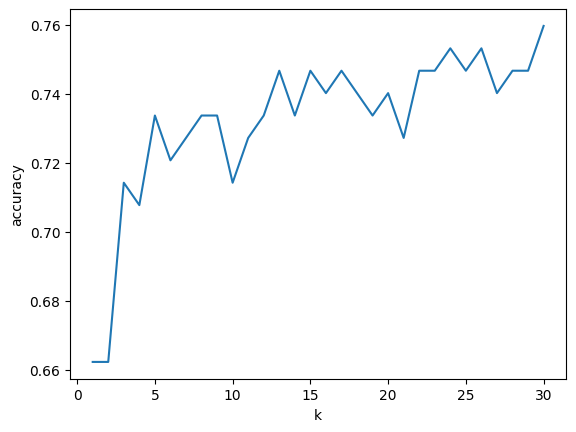

In [68]:
plt.plot(range(1,31),scores)
plt.xlabel("k")
plt.ylabel("accuracy")
plt.show()